# 目标检测


## 简介
### 区别
#### 图片分类
- 有一个主体的图片
- 识别单一类别

#### 目标检测
- 图片中有多个目标
- 识别多个类别
- 识别位置（边缘框）

### 边缘框
可以通过四个数字定义
- 左上x 左上y 右下x 右下y
- 左上x 左上y 宽 高
- 中心x 中心y 宽 高

### 数据集
每行表示一个物体，包含
- 图像文件名
- 类别
- 边缘框

最知名的数据集是 COCO，有 80 个类别，包含 33 万张图片，120 万个目标。

## 目标框实现


In [1]:
%matplotlib inline
import torch
import util
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import torchvision

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


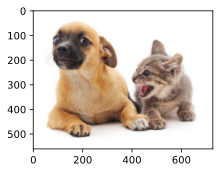

In [2]:
util.set_figsize()
img = plt.imread('./images/catdog.jpg')
plt.imshow(img)

在两种边缘框表示之间转换

In [3]:
def box_corner_to_center(boxes: torch.Tensor) -> torch.Tensor:
    """从左上角和右下角的坐标形式转换为中心点坐标形式"""
    # boxes (N, 4)，4 列分别是 (左上x, 左上y, 右下x, 右下y)
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w = x2 - x1
    h = y2 - y1
    return torch.stack((cx, cy, w, h), dim=-1) # (N, 4)

def box_center_to_corner(boxes: torch.Tensor) -> torch.Tensor:
    """从中心点坐标形式转换为左上角和右下角的坐标形式"""
    # boxes (N, 4)，4 列分别是 (中心x, 中心y, 宽, 高)
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    return torch.stack((x1, y1, x2, y2), dim=-1) # (N, 4)

图像中猫狗的边缘框

In [4]:
dog_bbox = [60.0, 45.0, 378.0, 516.0]
cat_bbox = [400.0, 112.0, 655.0, 493.0]

boxes = torch.tensor([dog_bbox, cat_bbox])
box_center_to_corner(box_corner_to_center(boxes)) == boxes

tensor([[True, True, True, True],
        [True, True, True, True]])

画出来

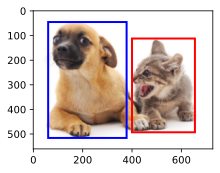

In [5]:
def bbox_to_rect(bbox, color):
    """将边缘框（左上角和右下角）格式转换为 Matplotlib 格式（左上坐标、高宽）"""
    return plt.Rectangle(xy=(bbox[0], bbox[1]),
                         width=bbox[2]-bbox[0],
                         height=bbox[3]-bbox[1],
                         fill=False, edgecolor=color, linewidth=2)

fig = plt.imshow(img)
fig.axes.add_patch(bbox_to_rect(dog_bbox, 'blue'))
fig.axes.add_patch(bbox_to_rect(cat_bbox, 'red'))

## 数据集
目标检测领域没有 CIFAR、MNIST 这样的小数据集，沐神整理了一个小的上课用。

In [6]:
util.data.DATA_HUB['banana-detection'] = (
    util.data.DATA_URL + 'banana-detection.zip',
    '5de26c8fce5ccdea9f91267273464dc968d20d72')

In [7]:
def read_data_bananas(is_train=True):
    """读取香蕉检测数据集中的图像和标签"""
    data_dir = util.data.download_extract('banana-detection')
    csv_fname = os.path.join(data_dir, 'bananas_train' if is_train
                             else 'bananas_val', 'label.csv')
    csv_data = pd.read_csv(csv_fname)
    csv_data = csv_data.set_index('img_name')
    images, targets = [], []
    for img_name, target in csv_data.iterrows():
        images.append(
            torchvision.io.read_image(
                os.path.join(data_dir,
                             'bananas_train' if is_train else
                             'bananas_val', 'images', f'{img_name}')))
        # 这里的target包含（类别，左上角x，左上角y，右下角x，右下角y），
        # 其中所有图像都具有相同的香蕉类（索引为0）
        targets.append(list(target))
    # 边框大小和位置 /256 变成 0~1 之间的数值
    return images, np.expand_dims(np.array(targets), 1) / 256

自定义 Dataset 类


In [8]:
class BananasDataset(torch.utils.data.Dataset):
    """一个用于加载香蕉检测数据集的自定义数据集"""
    def __init__(self, is_train=True):
        self.features, self.labels = read_data_bananas(is_train)
        print('read ' + str(len(self.features)) + (' training examples' if is_train else ' validation examples'))
    def __getitem__(self, idx):
        return self.features[idx].float(), torch.tensor(self.labels[idx])
    def __len__(self):
        return len(self.features)

数据加载器


In [9]:
def load_data_bananas(batch_size):
    """加载香蕉检测数据集"""
    train_iter = torch.utils.data.DataLoader(BananasDataset(is_train=True),
                                             batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(BananasDataset(is_train=False),
                                           batch_size)
    return train_iter, val_iter

检查批量中的图像和标签


In [10]:
batch_size = 32
edge_size = 256 # 图像边缘大小
train_iter, _ = load_data_bananas(batch_size)
batch = next(iter(train_iter))
features, label = batch
# (B, C, H, W)
print(features.shape)
# (B, T, 5)，其中 T 是每个图像中的目标数，5 是（类别，左上角x，左上角y，右下角x，右下角y）
print(label.shape)

read 1000 training examples
read 100 validation examples
torch.Size([32, 3, 256, 256])
torch.Size([32, 1, 5])


示范


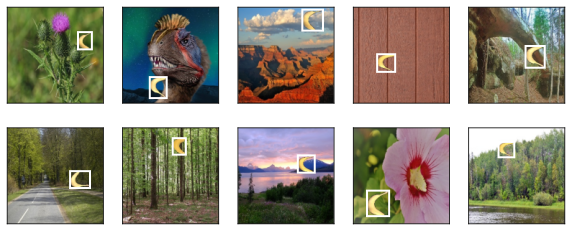

In [11]:
imgs = features[0:10].permute(0, 2, 3, 1) / 255
axes = util.show_images(imgs, 2, 5, scale=2)
for ax, lbl in zip(axes, label[0:10]):
    util.show_bboxes(ax, [lbl[0][1:5] * edge_size], colors=['w'])

这都是些啥？😂